# HistoMapTx Tutorial: Tissue Detection (Visium HD)

This tutorial shows how to use a tissue detection annotation exported from QuPath to filter background bins from Visium HD data.

## Overview

1. Load Visium HD data
2. Create a HistoMap object with the tissue detection GeoJSON
3. Compute overlap between bins and the tissue mask
4. Inspect coverage and save results for downstream filtering

> **Before starting:** See the [Input Files and QuPath Annotation Guide](0_Input_and_QuPath_annotation.ipynb) for how to generate the tissue detection GeoJSON using QuPath pixel thresholding.

## 1. Setting up the Environment

Import the necessary libraries and suppress warnings to keep the notebook clean.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Import required libraries
import spatialdata  # For handling spatial data objects
import spatialdata_io  # For reading spatial data formats
import histomaptx as hm  # Main package for annotation integration
import matplotlib.pyplot as plt  # For visualization

# Set figure size for better visualization
plt.rcParams['figure.figsize'] = [12, 10]

## 2. Creating the HistoMap Object

We need three key inputs:

| Input | Description |
|-------|-------------|
| `visium_path` | Path to the Space Ranger output folder |
| `annotation_file` | GeoJSON file exported from QuPath |
| `full_res_image` | Full-resolution image used for annotation and Space Ranger (`.tif`, `.btf`, `.svs`) |

> See the [Input Files and QuPath Annotation Guide](0_Input_and_QuPath_annotation.ipynb) for details on how to generate the GeoJSON and which image to annotate.

### 2.1 Set Paths

In [2]:
# Path to your Visium dataset folder (containing the SpaceRanger output)
visium_path = "/home/croizer/Documents/01_Ressources/02_Public_Visium/VisiumHD_colon"

# Path to QuPath annotation GeoJSON file
annotation_file = "/home/croizer/Documents/03_Paper/05_Histomap/colon/tissue_detect.geojson.gz"

# Path to full resolution TIFF image (the one used for annotation and SpaceRanger)
full_res_image = "/home/croizer/Documents/01_Ressources/02_Public_Visium/VisiumHD_colon/Visium_HD_Human_Colon_Cancer_tissue_image.btf"

In [3]:
# Load the Visium data using spatialdata_io
visium = spatialdata_io.visium_hd(visium_path, dataset_id="Visium_HD_Human_Colon_Cancer")

### 2.2 Choose Resolution

Visium HD data is available at multiple bin sizes. Choose the resolution you want to work with: `02`, `08`, or `16` micron bins.

In [4]:
resolution = '16'

### 2.3 Create the HistoMap Object

In [5]:
# Create a HistoMap object by combining the annotation file, Visium data, and the full resolution image
histomap = hm.HistoMap(annotation_file, visium, full_res_image, visium_type='visium_hd', bin_size=int(resolution))

# Display information about the HistoMap object
print(histomap)

HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Documents/03_Paper/05_Histomap/colon/tissue_detect.geojson.gz
📂 Full resolution image used: /home/croizer/Documents/01_Ressources/02_Public_Visium/VisiumHD_colon/Visium_HD_Human_Colon_Cancer_tissue_image.btf
🔢 Number of annotations present: 1
🏷 Annotations: Positive
🏷 Activated annotations: Positive
🏷 Disabled annotations: 

-------Spatial Data--------
Type is visium_hd

SpatialData object
├── Images
│     ├── 'Visium_HD_Human_Colon_Cancer_full_image': DataTree[cyx] (3, 48740, 75250), (3, 24370, 37625), (3, 12185, 18812), (3, 6092, 9406), (3, 3046, 4703)
│     ├── 'Visium_HD_Human_Colon_Cancer_hires_image': DataArray[cyx] (3, 3886, 6000)
│     └── 'Visium_HD_Human_Colon_Cancer_lowres_image': DataArray[cyx] (3, 389, 600)
├── Shapes
│     ├── 'Visium_HD_Human_Colon_Cancer_square_002um': GeoDataFrame shape: (8731400, 1) (2D shapes)
│     ├── 'Visium_HD_Human_Colon_Cancer_square_008um': GeoDataFrame shape: (5

## 3. Visualizing Annotations

Let's visualize the annotations imported from QuPath to confirm they are correctly aligned with the tissue.

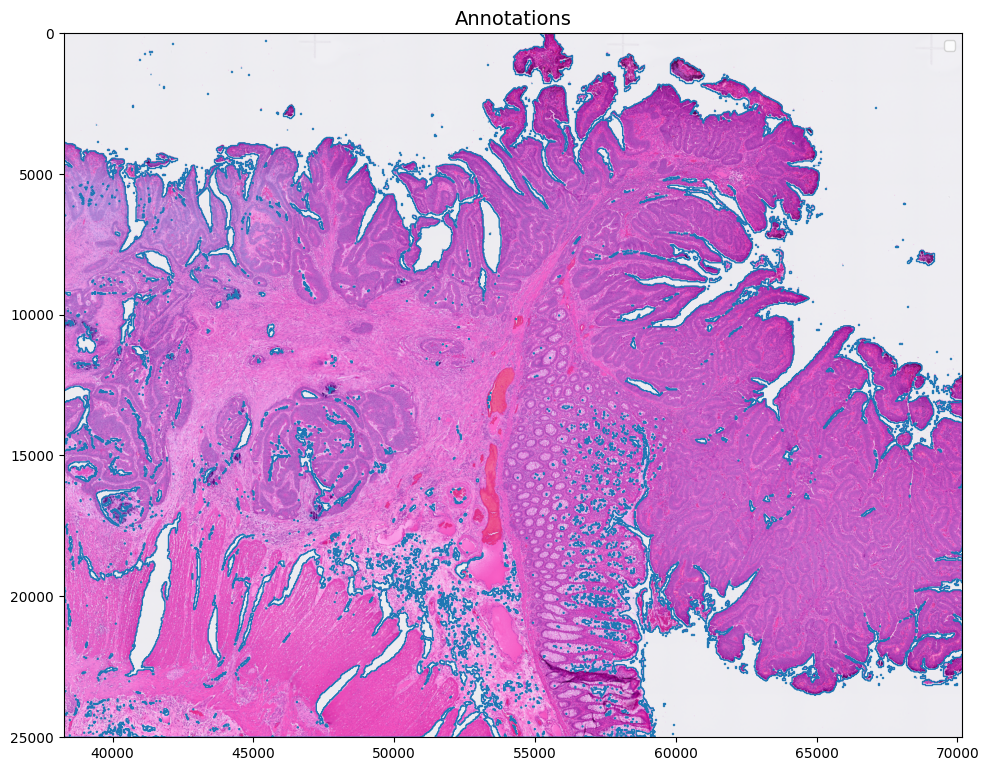

In [6]:
# Plot all annotations on the tissue image
hm.plot_annotations(histomap, display_image=True, fill=False)

## 4. Tissue Detection

Compute the overlap between each bin and the tissue mask. Bins with low overlap (e.g. < 5%) are likely background.

### 4.1 Compute Overlap

In [ ]:
histomap.compute_annotation_overlap('Positive')

Starting calculating overlap
1/1 layer processed: Positive
Intersecting spots: 129184
Updated 'Annotation_positive' for 'Positive' with threshold 50%.
Computed annotation overlap for: Positive. Updated Overlay status.


INFO     Using 'datashader' backend with 'mean' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


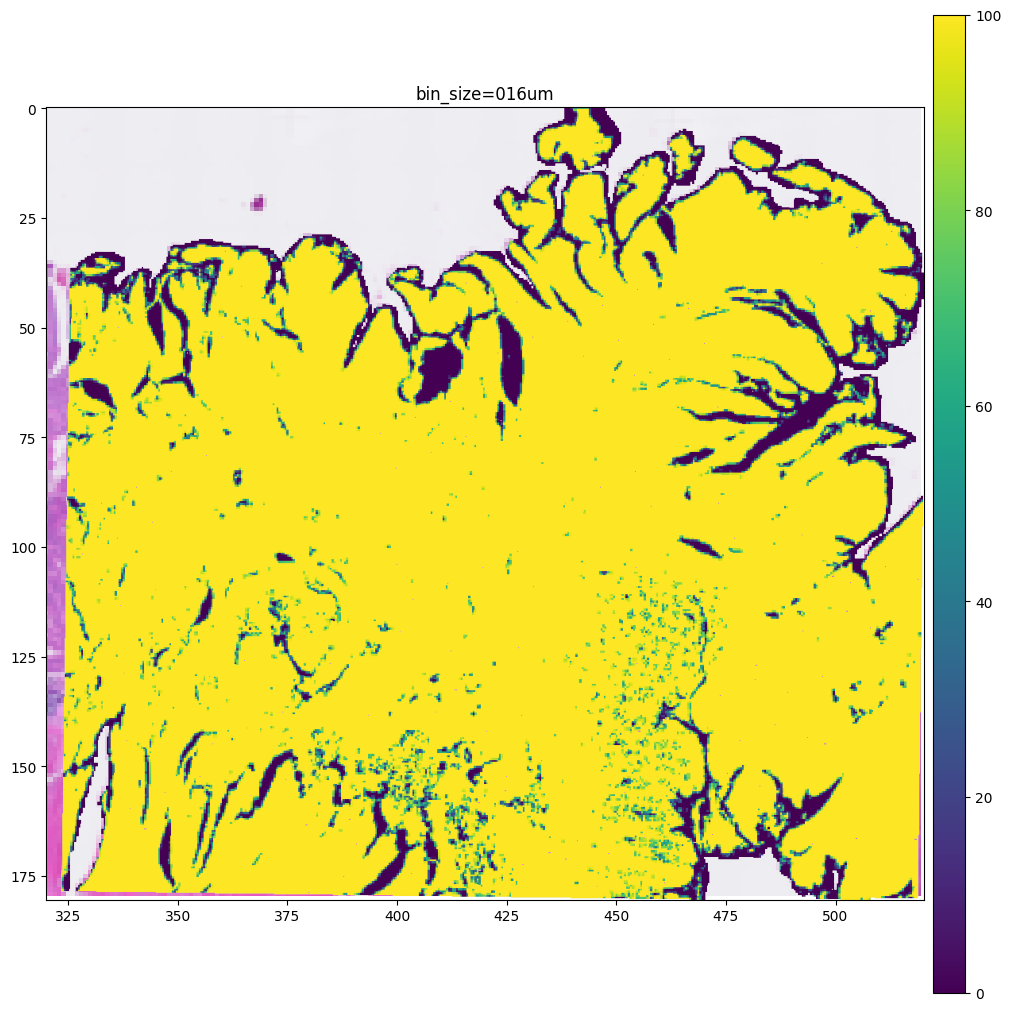

In [8]:
hm.plot_annotation_overlay(histomap, annotation= 'Positive', xcoords=(320, 520), ycoords=(0, 180))

### 4.2 Inspect Coverage

Visualise the distribution of tissue coverage per bin. Bins with low overlap (e.g. < 5%) are likely background and can be filtered out downstream.

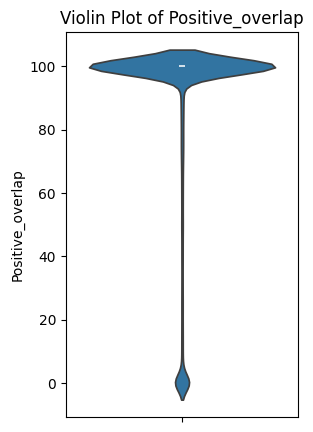

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

data = histomap.visium_spatialdata.tables['square_0'+resolution+'um'].obs['Positive_overlap'].values

plt.figure(figsize=(3, 5))  # width, height in inches
sns.violinplot(y=data)

plt.title("Violin Plot of Positive_overlap")
plt.ylabel("Positive_overlap")
plt.show()

### 4.3 Save Tissue Overlap Results

Save the overlap values so they can be merged with the annotation results later.

In [10]:
df = histomap.visium_spatialdata.tables['square_0'+resolution+'um'].obs
df.to_csv("/home/croizer/Documents/03_Paper/05_Histomap/colon/tissue_overlap_visium_barcode"+resolution+".csv")